# Model Training
Take-Home Test: Fraudulent Transaction Detection

by Sawit Koseeyaumporn

Perform train-test split, data preprocessing, model training, and handle imbalanced datasets for fraud detection on the dataframe `df`.

In [1]:
import pandas as pd

df = pd.read_csv("data/fraud_mock.csv")
df.head()

,time_ind,transac_type,amount,src_acc,src_bal,src_new_bal,dst_acc,dst_bal,dst_new_bal,is_fraud,is_flagged_fraud
0,1,PAYMENT,9839.64,acc910286,170136.0,160296.36,acc298089,0.0,0.0,0,0
1,1,PAYMENT,1864.28,acc6597009,21249.0,19384.72,acc8726693,0.0,0.0,0,0
2,1,TRANSFER,181.00,acc1796908,181.0,0.00,acc4938640,0.0,0.0,1,0
3,1,CASH_OUT,181.00,acc4182296,181.0,0.00,acc1221153,21182.0,0.0,1,0
4,1,PAYMENT,11668.14,acc7841596,41554.0,29885.86,acc5599142,0.0,0.0,0,0


* Filter the data to have only the transac_type of "TRANSFER" and "CASH_OUT"

In [2]:
df_filtered = df[df['transac_type'].isin(['TRANSFER', 'CASH_OUT'])].copy()
display(df_filtered.head())

,time_ind,transac_type,amount,src_acc,src_bal,src_new_bal,dst_acc,dst_bal,dst_new_bal,is_fraud,is_flagged_fraud
2,1,TRANSFER,181.00,acc1796908,181.0,0.0,acc4938640,0.0,0.00,1,0
3,1,CASH_OUT,181.00,acc4182296,181.0,0.0,acc1221153,21182.0,0.00,1,0
15,1,CASH_OUT,229133.94,acc7697333,15325.0,0.0,acc2123864,5083.0,51513.44,0,0
19,1,TRANSFER,215310.30,acc8579790,705.0,0.0,acc1511007,22425.0,0.00,0,0
24,1,TRANSFER,311685.89,acc5249602,10835.0,0.0,acc5114175,6267.0,2719172.89,0,0


## 1. Split data

Split the data into training and testing sets using the specified features and target variable, test size, and random state.

In [3]:
from sklearn.model_selection import train_test_split

X = df_filtered[['time_ind', 'transac_type', 'amount', 'src_bal', 'src_new_bal', 'dst_bal', 'dst_new_bal']]
y = df_filtered['is_fraud']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [7]:
len(X)

2770409

## 2. Feature selection
Based on the EDA, the most informative features are transaction type, amount, and account balance related columns.

In [4]:
relevant_features = ['transac_type', 'amount', 'src_bal', 'src_new_bal', 'dst_bal', 'dst_new_bal']

X_train = X_train[relevant_features]
X_test = X_test[relevant_features]

display(X_train.head())
display(X_test.head())

,transac_type,amount,src_bal,src_new_bal,dst_bal,dst_new_bal
1326860,CASH_OUT,256796.36,0.0,0.00,826969.43,1083765.80
3095732,CASH_OUT,76426.86,20808.0,0.00,398149.07,474575.92
4353969,CASH_OUT,173912.66,0.0,0.00,465746.64,639659.30
529479,CASH_OUT,197978.48,204571.0,6592.52,0.00,197978.48
3996516,CASH_OUT,352228.73,1484.0,0.00,163019.07,515247.80


,transac_type,amount,src_bal,src_new_bal,dst_bal,dst_new_bal
1442460,CASH_OUT,285073.76,229352.64,0.0,0.00,285073.76
5847267,CASH_OUT,204657.38,5093.00,0.0,911883.62,1116541.00
2163940,CASH_OUT,27554.10,0.00,0.0,154247.81,181801.91
2689116,CASH_OUT,100950.61,0.00,0.0,3946646.29,4047596.90
1452693,CASH_OUT,42737.06,0.00,0.0,409890.88,364619.44


## 3. Categorical feature encoding

Convert categorical features like `transac_type` into numerical representations using techniques one-hot encoding.

transac_type_TRANSFER = False is `CASH_OUT`

transac_type_TRANSFER = True is `TRANSFER`


In [5]:
X_train = pd.get_dummies(X_train, columns=['transac_type'], drop_first=True)
X_test = pd.get_dummies(X_test, columns=['transac_type'], drop_first=True)

# Ensure consistent columns between train and test sets
train_cols = X_train.columns
test_cols = X_test.columns

missing_in_test = set(train_cols) - set(test_cols)
for c in missing_in_test:
    X_test[c] = 0

missing_in_train = set(test_cols) - set(train_cols)
for c in missing_in_train:
    X_train[c] = 0

X_test = X_test[train_cols]

display(X_train.head())
display(X_test.head())

,amount,src_bal,src_new_bal,dst_bal,dst_new_bal,transac_type_TRANSFER
1326860,256796.36,0.0,0.00,826969.43,1083765.80,False
3095732,76426.86,20808.0,0.00,398149.07,474575.92,False
4353969,173912.66,0.0,0.00,465746.64,639659.30,False
529479,197978.48,204571.0,6592.52,0.00,197978.48,False
3996516,352228.73,1484.0,0.00,163019.07,515247.80,False


,amount,src_bal,src_new_bal,dst_bal,dst_new_bal,transac_type_TRANSFER
1442460,285073.76,229352.64,0.0,0.00,285073.76,False
5847267,204657.38,5093.00,0.0,911883.62,1116541.00,False
2163940,27554.10,0.00,0.0,154247.81,181801.91,False
2689116,100950.61,0.00,0.0,3946646.29,4047596.90,False
1452693,42737.06,0.00,0.0,409890.88,364619.44,False


In [6]:
X_train["transac_type_TRANSFER"].value_counts()

transac_type_TRANSFER
False    1789737
True      426590
Name: count, dtype: int64

## 4. Feature scaling

Scale numerical features with StandardScaler to ensure they have a similar range, which can improve the performance of some models.


In [9]:
from sklearn.preprocessing import StandardScaler

# Identify numerical columns to scale (excluding one-hot encoded columns)
numerical_cols_train = X_train.select_dtypes(include=['float64', 'int64']).columns
numerical_cols_test = X_test.select_dtypes(include=['float64', 'int64']).columns

# Instantiate StandardScaler
scaler = StandardScaler()

# Fit on training data and transform both training and testing data
X_train[numerical_cols_train] = scaler.fit_transform(X_train[numerical_cols_train])
X_test[numerical_cols_test] = scaler.transform(X_test[numerical_cols_test])

# Display the head of the scaled DataFrames
display(X_train.head())
display(X_test.head())

,amount,src_bal,src_new_bal,dst_bal,dst_new_bal,transac_type_TRANSFER
1326860,-0.068569,-0.191532,-0.108367,-0.207319,-0.206603,False
3095732,-0.272916,-0.107854,-0.108367,-0.308757,-0.336917,False
4353969,-0.162471,-0.191532,-0.108367,-0.292767,-0.301604,False
529479,-0.135206,0.631140,-0.063931,-0.402940,-0.396085,False
3996516,0.039550,-0.185565,-0.108367,-0.364378,-0.328217,False


,amount,src_bal,src_new_bal,dst_bal,dst_new_bal,transac_type_TRANSFER
1442460,-0.036532,0.730798,-0.108367,-0.402940,-0.377454,False
5847267,-0.127639,-0.171051,-0.108367,-0.187232,-0.199592,False
2163940,-0.328286,-0.191532,-0.108367,-0.366453,-0.399546,False
2689116,-0.245132,-0.191532,-0.108367,0.530648,0.427402,False
1452693,-0.311085,-0.191532,-0.108367,-0.305980,-0.360438,False


## 5. Handle imbalance

handle imbalance issue using techniques like oversampling (e.g., SMOTE) or undersampling on the training data.


In [12]:
from imblearn.over_sampling import SMOTE

smote = SMOTE(random_state=42)
X_train_resampled, y_train_resampled = smote.fit_resample(X_train, y_train)

print("Class distribution in original training data:")
print(y_train.value_counts())
print("\nClass distribution in resampled training data:")
print(y_train_resampled.value_counts())

Class distribution in original training data:
is_fraud
0    2209760
1       6567
Name: count, dtype: int64

Class distribution in resampled training data:
is_fraud
0    2209760
1    2209760
Name: count, dtype: int64


## 6. Model selection and training

Choose a suitable model for Tabular features using autoML like PyCaret to see the best model.


In [ ]:
from pycaret.classification import *
import pandas as pd

# Sample ด้วย 10000 rows จากข้อมูลทั้งหมดเพื่อดู Performance models แบบเร็วๆ
sample_size = min(10000, len(X_train_resampled))
sample_indices = X_train_resampled.sample(n=sample_size, random_state=42).index

X_train_sample = X_train_resampled.loc[sample_indices]
y_train_sample = y_train_resampled.loc[sample_indices]

print(f"Original resampled data size: {len(X_train_resampled)}")
print(f"Sampled data size for PyCaret: {len(X_train_sample)}")
print(f"Sampled class distribution:")
print(y_train_sample.value_counts())

# Combine X_train_sample and y_train_sample into a single DataFrame for PyCaret
data_resampled = X_train_sample.copy()
data_resampled['is_fraud'] = y_train_sample

exp_reg101 = setup(data = data_resampled, target = 'is_fraud', session_id = 123)

Original resampled data size: 4419520
Sampled data size for PyCaret: 10000
Sampled class distribution:
is_fraud
1    5013
0    4987
Name: count, dtype: int64


,Description,Value
0,Session id,123
1,Target,is_fraud
2,Target type,Binary
3,Original data shape,"(10000, 7)"
4,Transformed data shape,"(10000, 7)"
5,Transformed train set shape,"(7000, 7)"
6,Transformed test set shape,"(3000, 7)"
7,Numeric features,5
8,Preprocess,True
9,Imputation type,simple


In [11]:
best_model = compare_models()

,Model,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC,TT (Sec)
lightgbm,Light Gradient Boosting Machine,0.9931,0.9990,0.9969,0.9896,0.9932,0.9863,0.9863,29.9020
xgboost,Extreme Gradient Boosting,0.9914,0.9986,0.9969,0.9862,0.9915,0.9829,0.9829,0.0740
catboost,CatBoost Classifier,0.9911,0.9990,0.9969,0.9857,0.9912,0.9823,0.9824,3.1280
rf,Random Forest Classifier,0.9871,0.9990,0.9917,0.9828,0.9872,0.9743,0.9743,0.2720
dt,Decision Tree Classifier,0.9861,0.9861,0.9880,0.9844,0.9862,0.9723,0.9723,0.0210
et,Extra Trees Classifier,0.9859,0.9986,0.9892,0.9828,0.9859,0.9717,0.9718,0.1710
gbc,Gradient Boosting Classifier,0.9859,0.9976,0.9974,0.9750,0.9861,0.9717,0.9720,0.4060
knn,K Neighbors Classifier,0.9663,0.9896,0.9778,0.9560,0.9667,0.9326,0.9329,0.0450
ada,Ada Boost Classifier,0.9657,0.9941,0.9746,0.9578,0.9661,0.9314,0.9316,0.1350
lr,Logistic Regression,0.9187,0.9820,0.8926,0.9423,0.9167,0.8374,0.8387,0.6090


ฉะนั้นจากที่เราเห็นจะสังเกตว่า LightGBM ให้ Accuracy สูงสุด แต่ว่าเวลาที่ใช้ในการ Inference นานเกินไป จึงเลือกเป็น XGBoost ที่มีความเร็วสูงสุดในขณะที่ Accuracy ยังเป็นอันดับ 2

In [14]:
import optuna
from xgboost import XGBClassifier
from sklearn.model_selection import cross_val_score
import numpy as np

# Define Optuna objective function for hyperparameter tuning
def objective(trial):
    # Define hyperparameter search space
    params = {
        'max_depth': trial.suggest_int('max_depth', 3, 10),
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.3, log=True),
        'n_estimators': trial.suggest_int('n_estimators', 100, 500),
        'min_child_weight': trial.suggest_int('min_child_weight', 1, 10),
        'subsample': trial.suggest_float('subsample', 0.6, 1.0),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.6, 1.0),
        'gamma': trial.suggest_float('gamma', 0, 5),
        'reg_alpha': trial.suggest_float('reg_alpha', 0, 2),
        'reg_lambda': trial.suggest_float('reg_lambda', 0, 2),
        'random_state': 42,
        'eval_metric': 'logloss',
        'use_label_encoder': False
    }
    
    # Create model with suggested hyperparameters
    model = XGBClassifier(**params)
    
    # Perform 5-fold cross-validation on a sample (for speed)
    # Use full data if you have time, or adjust sample size
    cv_sample_size = min(50000, len(X_train_resampled))
    cv_indices = np.random.choice(len(X_train_resampled), cv_sample_size, replace=False)
    X_cv = X_train_resampled.iloc[cv_indices]
    y_cv = y_train_resampled.iloc[cv_indices]
    
    # Cross-validation with F1 score (important for imbalanced data)
    cv_scores = cross_val_score(model, X_cv, y_cv, cv=5, scoring='f1', n_jobs=-1)
    
    return cv_scores.mean()

# Run Optuna optimization
print("Starting Optuna hyperparameter optimization...")
print("This may take several minutes...\n")

study = optuna.create_study(direction='maximize', study_name='xgboost_fraud_detection')
study.optimize(objective, n_trials=50, show_progress_bar=True)

# Display best parameters
print(f"\nBest F1 Score (CV): {study.best_value:.4f}")
print(f"\nBest Hyperparameters:")
for key, value in study.best_params.items():
    print(f"  {key}: {value}")

# Train final model with best parameters on full resampled data
print("\n" + "="*60)
print("Training final model with best parameters on full data...")
print("="*60)

best_params = study.best_params
best_params['random_state'] = 42
best_params['eval_metric'] = 'logloss'
best_params['use_label_encoder'] = False

model = XGBClassifier(**best_params)
model.fit(X_train_resampled, y_train_resampled)

print("\n✅ Model training complete!")
print(f"Model parameters: {model.get_params()}")

[I 2025-11-07 15:08:30,162] A new study created in memory with name: xgboost_fraud_detection


Starting Optuna hyperparameter optimization...
This may take several minutes...



  0%|          | 0/50 [00:00<?, ?it/s]

C:\Users\Sawit\AppData\Roaming\Python\Python312\site-packages\xgboost\sklearn.py:1395: UserWarning: `use_label_encoder` is deprecated in 1.7.0.
  warnings.warn("`use_label_encoder` is deprecated in 1.7.0.")
C:\Users\Sawit\AppData\Roaming\Python\Python312\site-packages\xgboost\sklearn.py:1395: UserWarning: `use_label_encoder` is deprecated in 1.7.0.
  warnings.warn("`use_label_encoder` is deprecated in 1.7.0.")


[I 2025-11-07 15:08:40,773] Trial 0 finished with value: 0.9869929686461308 and parameters: {'max_depth': 5, 'learning_rate': 0.016466115029298702, 'n_estimators': 453, 'min_child_weight': 2, 'subsample': 0.9713352428087652, 'colsample_bytree': 0.6329782892540888, 'gamma': 4.346723621318233, 'reg_alpha': 0.7378862038006264, 'reg_lambda': 0.8590986939884355}. Best is trial 0 with value: 0.9869929686461308.


...

[I 2025-11-07 15:17:21,175] Trial 47 finished with value: 0.9931351234084529 and parameters: {'max_depth': 5, 'learning_rate': 0.2555168323612349, 'n_estimators': 158, 'min_child_weight': 5, 'subsample': 0.9206516149576972, 'colsample_bytree': 0.9792625058306775, 'gamma': 0.7385872075715118, 'reg_alpha': 1.6107799852745717, 'reg_lambda': 0.3056916095036978}. Best is trial 33 with value: 0.9952651820973083.


C:\Users\Sawit\AppData\Roaming\Python\Python312\site-packages\xgboost\sklearn.py:1395: UserWarning: `use_label_encoder` is deprecated in 1.7.0.
  warnings.warn("`use_label_encoder` is deprecated in 1.7.0.")


[I 2025-11-07 15:17:29,385] Trial 48 finished with value: 0.9940528826805242 and parameters: {'max_depth': 6, 'learning_rate': 0.1590288565466474, 'n_estimators': 348, 'min_child_weight': 4, 'subsample': 0.9784263187542042, 'colsample_bytree': 0.9273249718493332, 'gamma': 0.0665385131743173, 'reg_alpha': 1.45411022035464, 'reg_lambda': 0.2659670175577457}. Best is trial 33 with value: 0.9952651820973083.


C:\Users\Sawit\AppData\Roaming\Python\Python312\site-packages\xgboost\sklearn.py:1395: UserWarning: `use_label_encoder` is deprecated in 1.7.0.
  warnings.warn("`use_label_encoder` is deprecated in 1.7.0.")


[I 2025-11-07 15:17:40,040] Trial 49 finished with value: 0.9944317936098072 and parameters: {'max_depth': 7, 'learning_rate': 0.20885665038176546, 'n_estimators': 423, 'min_child_weight': 1, 'subsample': 0.8548189209469109, 'colsample_bytree': 0.7584531575183868, 'gamma': 1.6289708727727805, 'reg_alpha': 1.7250080563843808, 'reg_lambda': 0.00021060280121002178}. Best is trial 33 with value: 0.9952651820973083.

Best F1 Score (CV): 0.9953

Best Hyperparameters:
  max_depth: 9
  learning_rate: 0.061301404409224415
  n_estimators: 469
  min_child_weight: 2
  subsample: 0.9752037993482521
  colsample_bytree: 0.8573880867275121
  gamma: 0.638993388354699
  reg_alpha: 0.29480625211096934
  reg_lambda: 0.5622110080376844

Training final model with best parameters on full data...

✅ Model training complete!
Model parameters: {'objective': 'binary:logistic', 'use_label_encoder': False, 'base_score': None, 'booster': None, 'callbacks': None, 'colsample_bylevel': None, 'colsample_bynode': None, 

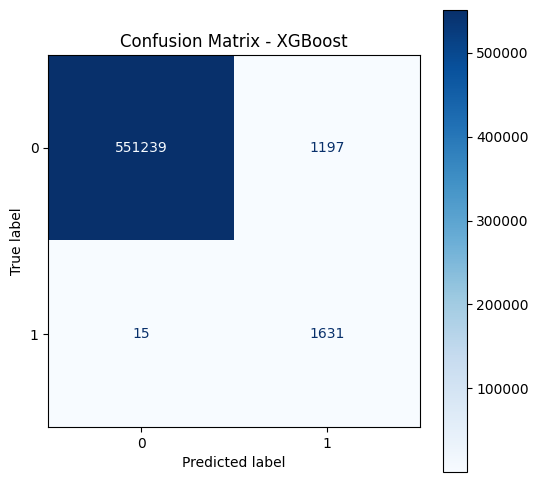

              precision    recall  f1-score   support

           0     1.0000    0.9978    0.9989    552436
           1     0.5767    0.9909    0.7291      1646

    accuracy                         0.9978    554082
   macro avg     0.7884    0.9944    0.8640    554082
weighted avg     0.9987    0.9978    0.9981    554082



In [16]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report

import matplotlib.pyplot as plt

# Predict on the test set
y_pred = model.predict(X_test)

# Confusion matrix
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=model.classes_)

fig, ax = plt.subplots(figsize=(6, 6))
disp.plot(ax=ax, cmap="Blues", values_format='d')
ax.set_title("Confusion Matrix - XGBoost")
plt.show()

# Classification report for precision/recall/f1
print(classification_report(y_test, y_pred, digits=4))

Metrics ที่เราใช้ในการเทรนด์คือ F1-score เนื่องจาก เราต้องการ Balanced ระหว่าง Precision กับ Recall

แต่จากผลลัพธ์ที่เราได้ Confusion Matrix พบว่า Recall ค่อนข้างดี (ซึ่งเป็นผลดี เพราะว่าถ้าหากผิดจริงแล้วเราปล่อย อาจจะทำให้เสียหายมากกว่า) แต่ในขณะที่ Precision ยังไม่ค่อยดีเท่าไหร่ประมาณ 0.78 เบื้องต้นสามารถใช้งานโมเดลนี้ได้ขั้นต้น แต่อาจจะลองปรับ Model เพิ่มเติม หรือไปใช้โมเดลประเภท Anomaly Detection แทน

## Save models

In [15]:
import os
import joblib
import json

os.makedirs("models", exist_ok=True)

# Save XGBoost native model (portable)
model.save_model("models/xgb_model.json")

# Save full sklearn-compatible object (includes Python state)
joblib.dump(model, "models/xgb_model.joblib")

# Save preprocessing & metadata for future inference
artifacts = {
    "scaler": scaler,
    "train_cols": list(train_cols),
    "numerical_cols": list(numerical_cols_train),
    "best_params": best_params
}
joblib.dump(artifacts, "models/preprocessing_artifacts.joblib")

# Also save train_cols as JSON for quick inspection
with open("models/train_cols.json", "w") as f:
    json.dump(list(train_cols), f)

print("Saved model and artifacts to ./models/")

Saved model and artifacts to ./models/
